In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [35]:
df = pd.read_csv('NFL Play by Play 2009-2016 (v3).csv')
print("Data loaded successfully.")

df.head()

/var/folders/pc/qpl83vwd53v_hm0hj90d3nz00000gn/T/ipykernel_38895/908466908.py:1: DtypeWarning: Columns (25,51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('NFL Play by Play 2009-2016 (v3).csv')


Data loaded successfully.


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,...,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


In [ ]:
# Check for missing values
print("Null count per column:")
print(df.isnull().sum())

# Display DataFrame info
print("DataFrame info:")
print(df.head(10).info())


Null count per column:
Date             0
GameID           0
Drive            0
qtr              0
down         54218
             ...  
Win_Prob     21993
WPA           4817
airWPA      220738
yacWPA      220956
Season           0
Length: 102, dtype: int64
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Columns: 102 entries, Date to Season
dtypes: float64(33), int64(31), object(38)
memory usage: 8.1+ KB
None


In [45]:
# Get the columns
columns = df.columns.tolist()
print("Columns in the DataFrame:")
print(columns)

Columns in the DataFrame:
['Date', 'GameID', 'Drive', 'qtr', 'down', 'time', 'TimeUnder', 'TimeSecs', 'PlayTimeDiff', 'SideofField', 'yrdln', 'yrdline100', 'ydstogo', 'ydsnet', 'GoalToGo', 'FirstDown', 'posteam', 'DefensiveTeam', 'desc', 'PlayAttempted', 'Yards.Gained', 'sp', 'Touchdown', 'ExPointResult', 'TwoPointConv', 'DefTwoPoint', 'Safety', 'Onsidekick', 'PuntResult', 'PlayType', 'Passer', 'Passer_ID', 'PassAttempt', 'PassOutcome', 'PassLength', 'AirYards', 'YardsAfterCatch', 'QBHit', 'PassLocation', 'InterceptionThrown', 'Interceptor', 'Rusher', 'Rusher_ID', 'RushAttempt', 'RunLocation', 'RunGap', 'Receiver', 'Receiver_ID', 'Reception', 'ReturnResult', 'Returner', 'BlockingPlayer', 'Tackler1', 'Tackler2', 'FieldGoalResult', 'FieldGoalDistance', 'Fumble', 'RecFumbTeam', 'RecFumbPlayer', 'Sack', 'Challenge.Replay', 'ChalReplayResult', 'Accepted.Penalty', 'PenalizedTeam', 'PenaltyType', 'PenalizedPlayer', 'Penalty.Yards', 'PosTeamScore', 'DefTeamScore', 'ScoreDiff', 'AbsScoreDiff', 

In [42]:
# fill in missing values in numerical columns with the median of the column

numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

# fill in missing values in categorical columns with the mode of the column
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_value = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
    df[col].fillna(mode_value, inplace=True)


df.head()


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,2.0,15:00,15,3600.0,0.0,TEN,...,0.000000,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,0.003557,0.000000,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,0.000000,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.003557,0.000000,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.003557,0.000000,2009


In [44]:
print("After filling missing values in columns:")
print(df.isnull().sum())
print(f"There are {df.isnull().sum().sum()} total missing values in the DataFrame.")

After filling missing values in columns:
Date        0
GameID      0
Drive       0
qtr         0
down        0
           ..
Win_Prob    0
WPA         0
airWPA      0
yacWPA      0
Season      0
Length: 102, dtype: int64
There are 0 total missing values in the DataFrame.


In [50]:
# Feature engineering and model training would go here

# Get the date features
df["Month"]= pd.to_datetime(df["Date"]).dt.month
df["DayOfWeek"] = pd.to_datetime(df["Date"]).dt.dayofweek
df["isWeekend"] = df["DayOfWeek"].apply(lambda x: 1 if x >=5 else 0)

# Get the game phase
df['IsFirstHalf'] = (df['qtr'] <= 2).astype(bool)
df['IsFourthQuarter'] = (df['qtr'] == 4).astype(bool)
df['TwoMinuteWarning'] = ((df['qtr'].isin([2, 4])) & (df['TimeSecs'] <= 120)).astype(bool)


df.head(40)

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,WPA,airWPA,yacWPA,Season,Month,DayOfWeek,isWeekend,IsFirstHalf,IsFourthQuarter,TwoMinuteWarning
0,2009-09-10,2009091000,1,1,2.0,15:00,15,3600.0,0.0,TEN,...,0.060758,0.003557,0.000000,2009,9,3,0,True,False,False
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,0.004655,-0.032244,0.036899,2009,9,3,0,True,False,False
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,-0.040295,0.003557,0.000000,2009,9,3,0,True,False,False
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-0.049576,0.106663,-0.156239,2009,9,3,0,True,False,False
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,0.097712,0.003557,0.000000,2009,9,3,0,True,False,False
5,2009-09-10,2009091000,2,1,1.0,13:16,14,3496.0,11.0,TEN,...,-0.019524,0.003557,0.000000,2009,9,3,0,True,False,False
6,2009-09-10,2009091000,2,1,2.0,12:40,13,3460.0,36.0,TEN,...,-0.004427,-0.010456,0.006029,2009,9,3,0,True,False,False
7,2009-09-10,2009091000,2,1,3.0,12:11,13,3431.0,29.0,TEN,...,-0.034663,0.003557,0.000000,2009,9,3,0,True,False,False
8,2009-09-10,2009091000,2,1,4.0,11:34,12,3394.0,37.0,TEN,...,0.026054,0.003557,0.000000,2009,9,3,0,True,False,False
9,2009-09-10,2009091000,3,1,1.0,11:24,12,3384.0,10.0,TEN,...,-0.006084,-0.024526,0.018442,2009,9,3,0,True,False,False


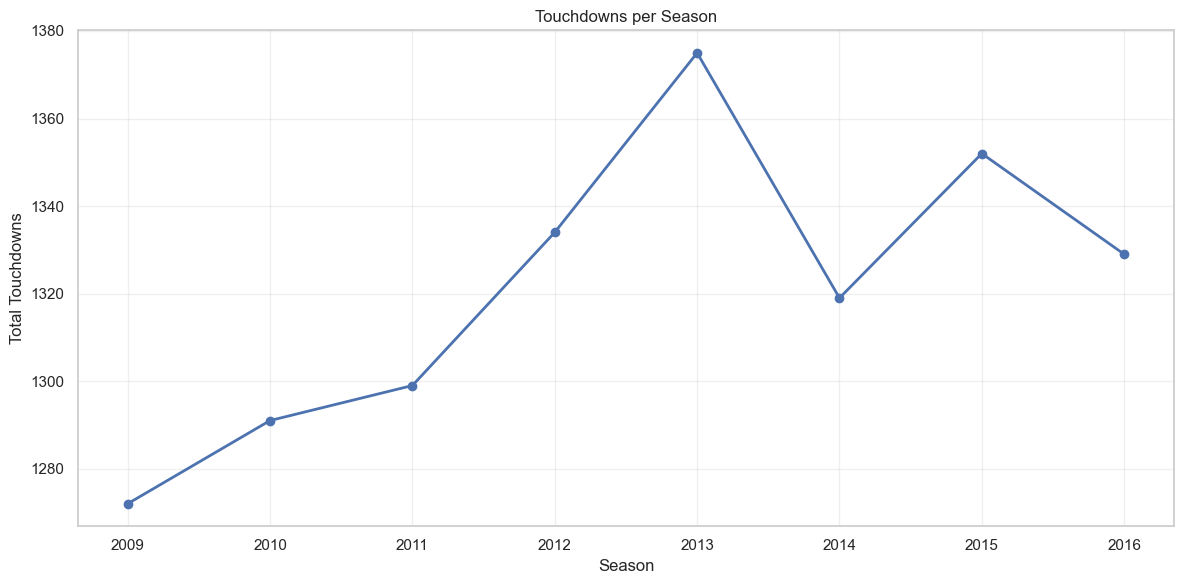

In [51]:
# Scoring over seasons
scoring_by_season = df.groupby('Season')['Touchdown'].sum()
plt.figure(figsize=(12, 6))
plt.plot(scoring_by_season.index, scoring_by_season.values, marker='o', linewidth=2)
plt.xlabel('Season')
plt.ylabel('Total Touchdowns')
plt.title('Touchdowns per Season')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

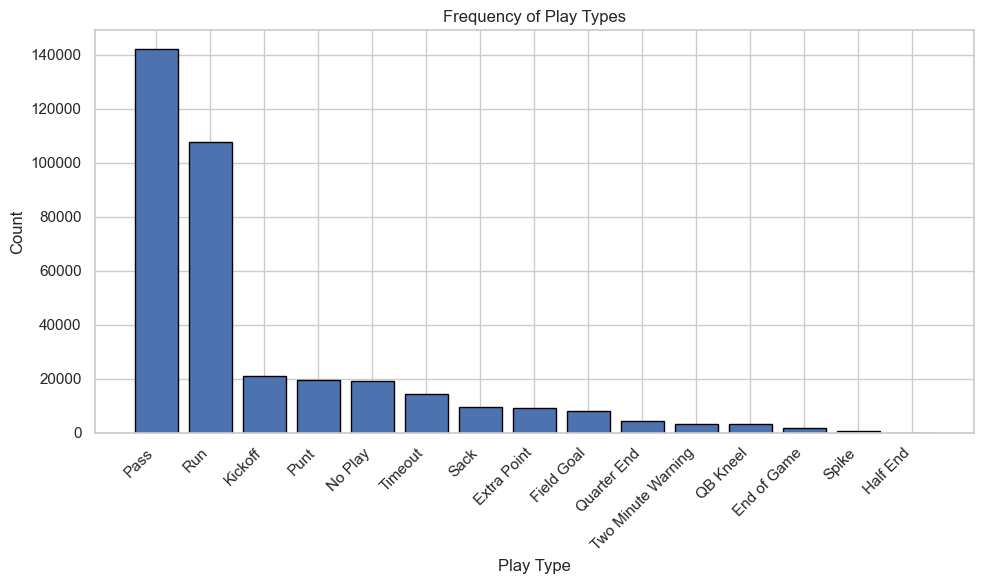

In [52]:
# Play type frequency
play_counts = df['PlayType'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(play_counts.index, play_counts.values, edgecolor='black')
plt.xlabel('Play Type')
plt.ylabel('Count')
plt.title('Frequency of Play Types')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

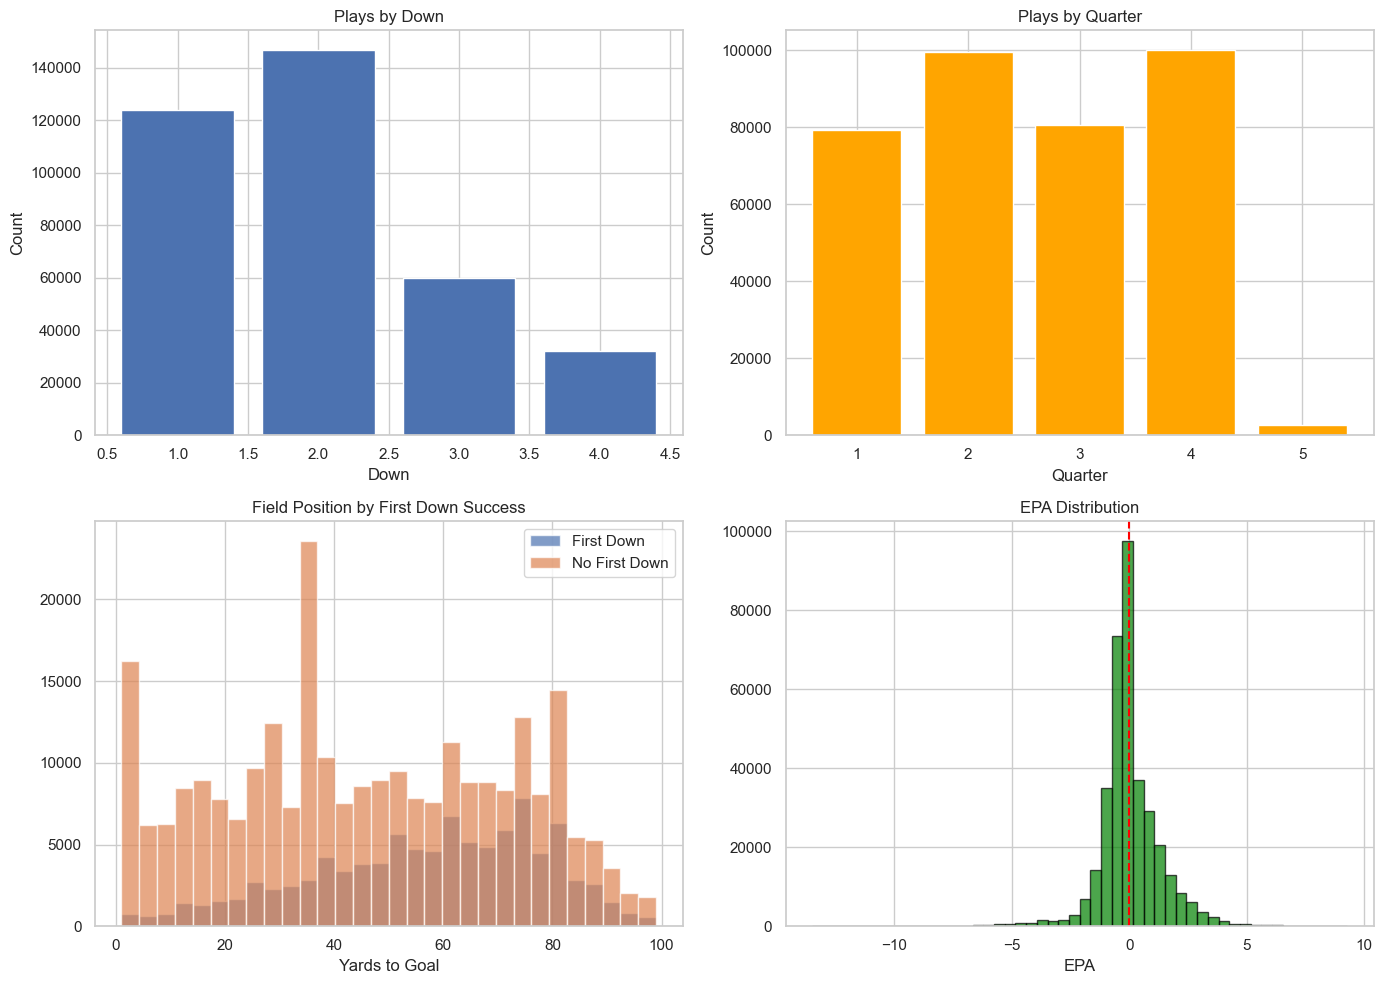

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Downs distribution
axes[0, 0].bar(df['down'].value_counts().sort_index().index, 
               df['down'].value_counts().sort_index().values)
axes[0, 0].set_title('Plays by Down')
axes[0, 0].set_xlabel('Down')
axes[0, 0].set_ylabel('Count')

# 2. Quarter distribution
axes[0, 1].bar(df['qtr'].value_counts().sort_index().index,
               df['qtr'].value_counts().sort_index().values, color='orange')
axes[0, 1].set_title('Plays by Quarter')
axes[0, 1].set_xlabel('Quarter')
axes[0, 1].set_ylabel('Count')

# 3. Success by field position
axes[1, 0].hist(df[df['FirstDown']==1]['yrdline100'], bins=30, alpha=0.7, label='First Down')
axes[1, 0].hist(df[df['FirstDown']==0]['yrdline100'], bins=30, alpha=0.7, label='No First Down')
axes[1, 0].set_title('Field Position by First Down Success')
axes[1, 0].set_xlabel('Yards to Goal')
axes[1, 0].legend()

# 4. EPA distribution
axes[1, 1].hist(df['EPA'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_title('EPA Distribution')
axes[1, 1].set_xlabel('EPA')
axes[1, 1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()